<a href="https://colab.research.google.com/github/KVaishali810/Churn-Intel/blob/main/gene_expression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install biopython

In [17]:
from Bio import Entrez, SeqIO
from Bio.SeqUtils import gc_fraction
print("Biopython imported successfully!")
print(f"Biopython version: {__import__('Bio').__version__}")

Biopython imported successfully!
Biopython version: 1.86


In [18]:
# ============================================
#   Gene Expression Differential Analysis
#   Tools: pandas, scipy, matplotlib
# ============================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# --- create count matrix ---
data = {
    'Gene'      : ['BRCA1', 'TP53', 'EGFR', 'GAPDH', 'MYC',
                   'VEGF', 'CDK2', 'PTEN', 'RAS', 'AKT'],
    'Control1'  : [120, 89, 200, 500, 80, 150, 300, 250, 180, 220],
    'Control2'  : [134, 92, 210, 510, 85, 160, 310, 245, 175, 215],
    'Control3'  : [118, 85, 195, 498, 78, 145, 295, 255, 185, 225],
    'Treat1'    : [450, 88, 850, 505, 320, 600, 290, 80,  540, 650],
    'Treat2'    : [478, 90, 900, 498, 340, 580, 285, 75,  560, 670],
    'Treat3'    : [465, 87, 875, 502, 330, 590, 295, 85,  550, 660],
}

df = pd.DataFrame(data)
df = df.set_index('Gene')

print("===== Raw Count Matrix =====")
print(df)
print(f"\nGenes   : {df.shape[0]}")
print(f"Samples : {df.shape[1]}")

===== Raw Count Matrix =====
       Control1  Control2  Control3  Treat1  Treat2  Treat3
Gene                                                       
BRCA1       120       134       118     450     478     465
TP53         89        92        85      88      90      87
EGFR        200       210       195     850     900     875
GAPDH       500       510       498     505     498     502
MYC          80        85        78     320     340     330
VEGF        150       160       145     600     580     590
CDK2        300       310       295     290     285     295
PTEN        250       245       255      80      75      85
RAS         180       175       185     540     560     550
AKT         220       215       225     650     670     660

Genes   : 10
Samples : 6


In [19]:
# --- normalize to CPM ---
cpm = df.copy()

for col in df.columns:
    total = df[col].sum()
    cpm[col] = (df[col] / total) * 1e6

print("===== Normalized Count Matrix (CPM) =====")
print(cpm.round(2))

# split into control and treatment
control = cpm[['Control1', 'Control2', 'Control3']]
treat   = cpm[['Treat1', 'Treat2', 'Treat3']]

print("\nControl mean CPM:")
print(control.mean(axis=1).round(2))
print("\nTreatment mean CPM:")
print(treat.mean(axis=1).round(2))

===== Normalized Count Matrix (CPM) =====
        Control1   Control2   Control3     Treat1     Treat2     Treat3
Gene                                                                   
BRCA1   57443.75   62734.08   56758.06  102904.18  106791.78  104753.32
TP53    42604.12   43071.16   40885.04   20123.49   20107.24   19599.01
EGFR    95739.59   98314.61   93795.09  194374.57  201072.39  197116.47
GAPDH  239348.97  238764.04  239538.24  115481.36  111260.05  113088.53
MYC     38295.84   39794.01   37518.04   73176.31   75960.68   74341.07
VEGF    71804.69   74906.37   69745.07  137205.58  129579.98  132912.82
CDK2   143609.38  145131.09  141895.14   66316.03   63672.92   66456.41
PTEN   119674.49  114700.37  122655.12   18294.08   16756.03   19148.46
RAS     86165.63   81928.84   88985.09  123485.02  125111.71  123901.78
AKT    105313.55  100655.43  108225.11  148639.38  149687.22  148682.14

Control mean CPM:
Gene
BRCA1     58978.63
TP53      42186.77
EGFR      95949.76
GAPDH    2392

In [20]:
# --- calculate log2 fold change and p-values ---
results = []

for gene in cpm.index:
    ctrl_values  = control.loc[gene].values
    treat_values = treat.loc[gene].values

    # mean expression
    ctrl_mean  = np.mean(ctrl_values)
    treat_mean = np.mean(treat_values)

    # log2 fold change
    # add 1 to avoid log(0)
    log2fc = np.log2(treat_mean + 1) - np.log2(ctrl_mean + 1)

    # t-test to get p-value
    tstat, pvalue = stats.ttest_ind(treat_values, ctrl_values)

    results.append({
        'Gene'       : gene,
        'Control_mean' : round(ctrl_mean, 2),
        'Treat_mean'   : round(treat_mean, 2),
        'log2FC'       : round(log2fc, 3),
        'pvalue'       : round(pvalue, 6)
    })

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Gene')

# sort by absolute log2FC
results_df = results_df.reindex(
    results_df['log2FC'].abs().sort_values(ascending=False).index
)

print("===== Differential Expression Results =====")
print(results_df)

===== Differential Expression Results =====
       Control_mean  Treat_mean  log2FC    pvalue
Gene                                             
PTEN      119009.99    18066.19  -2.720  0.000002
CDK2      143545.20    65481.79  -1.132  0.000000
TP53       42186.77    19943.24  -1.081  0.000005
GAPDH     239217.09   113276.65  -1.078  0.000000
EGFR       95949.76   197521.14   1.042  0.000002
MYC        38535.96    74492.69   0.951  0.000004
VEGF       72152.04   133232.79   0.885  0.000022
BRCA1      58978.63   104816.43   0.830  0.000031
RAS        85693.19   124166.17   0.535  0.000053
AKT       104731.36   149002.91   0.509  0.000038


/tmp/ipykernel_2835/3856699055.py:11: RuntimeWarning: divide by zero encountered in log10
  neglog10p = -np.log10(pval)


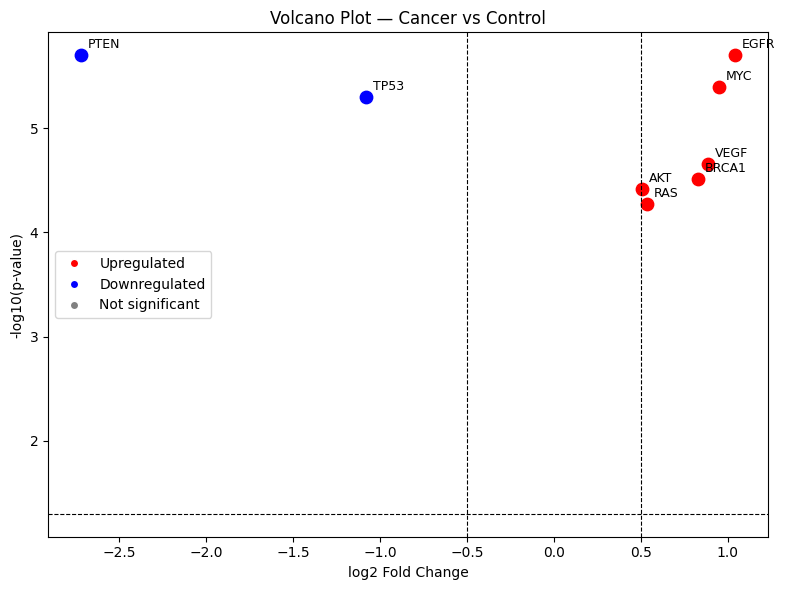

Volcano plot saved 


In [21]:
# --- volcano plot ---
fig, ax = plt.subplots(figsize=(8, 6))

# define thresholds
fc_threshold = 0.5      # log2FC cutoff
pval_threshold = 0.05   # p-value cutoff

for gene in results_df.index:
    log2fc = results_df.loc[gene, 'log2FC']
    pval   = results_df.loc[gene, 'pvalue']
    neglog10p = -np.log10(pval)

    # color based on significance
    if log2fc >= fc_threshold and pval < pval_threshold:
        color = 'red'      # upregulated
        label = 'up'
    elif log2fc <= -fc_threshold and pval < pval_threshold:
        color = 'blue'     # downregulated
        label = 'down'
    else:
        color = 'gray'     # not significant
        label = 'ns'

    ax.scatter(log2fc, neglog10p, color=color, s=80)
    ax.annotate(gene, (log2fc, neglog10p),
                textcoords="offset points",
                xytext=(5, 5), fontsize=9)

# threshold lines
ax.axvline(x= fc_threshold,  color='black',
           linestyle='--', linewidth=0.8)
ax.axvline(x=-fc_threshold,  color='black',
           linestyle='--', linewidth=0.8)
ax.axhline(y=-np.log10(pval_threshold),
           color='black', linestyle='--', linewidth=0.8)

ax.set_xlabel('log2 Fold Change')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Volcano Plot — Cancer vs Control')

# legend
from matplotlib.lines import Line2D
legend = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='red',  label='Upregulated'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='blue', label='Downregulated'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='gray', label='Not significant')
]
ax.legend(handles=legend)

plt.tight_layout()
plt.savefig('volcano_plot.png')
plt.show()
print("Volcano plot saved ")